# Programa de Capacitação de Processamento Digital de Sinais

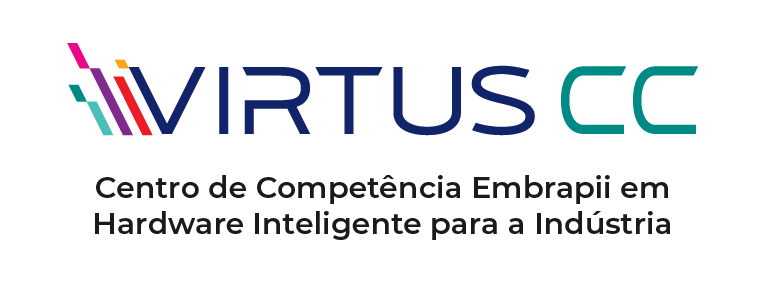


### Desenvolvido por:
-   Elmer Pimentel Farias



### Capítulos 4, 5 e 6 — Filtros Digitais  
**Baseado no livro “Processamento Digital de Sinais” — Paulo S. R. Diniz**

---

## Capítulo 4 — Filtros Digitais
O Capítulo 4 apresenta os fundamentos dos **filtros digitais**, dispositivos utilizados para modificar o espectro de um sinal de acordo com critérios de frequência.

São discutidos:
- As classificações: **passa-baixas**, **passa-altas**, **passa-faixa** e **rejeita-faixa**;  
- As diferenças entre filtros de **resposta ao impulso finita (FIR)** e **resposta ao impulso infinita (IIR)**;  
- A representação em **domínio Z**, o **diagrama de polos e zeros** e a **resposta em frequência**.

---

## Capítulo 5 — Filtros FIR
Os filtros **FIR (Finite Impulse Response)** possuem resposta ao impulso de duração finita, garantindo **estabilidade incondicional** e **fase linear**.

O capítulo enfatiza o **método de projeto por janelamento**, em especial o uso da **janela de Hamming**, que permite controlar a largura de banda e a atenuação do filtro.  
A análise da **resposta em frequência** e da **fase** é essencial para avaliar o desempenho e a seletividade do filtro.

---

## Capítulo 6 — Filtros IIR
Os filtros **IIR (Infinite Impulse Response)** são caracterizados pela **realimentação**, o que proporciona maior eficiência e seletividade espectral.  
Contudo, exigem cuidado com a **estabilidade** e a **linearidade de fase**.

São estudados os principais tipos:
- **Butterworth:** resposta suave e monotônica;  
- **Chebyshev:** maior seletividade à custa de ondulações na banda passante;  
- **Elíptico:** alta seletividade, porém com ondulações em ambas as bandas.

---

## Objetivos da Capacitação

1. **Projetar e aplicar** um **filtro FIR passa-baixas** utilizando a **janela de Hamming** em sinais ruidosos, comparando os sinais de entrada e saída.  
2. **Projetar e aplicar** um **filtro IIR Butterworth passa-altas** em sinais ruidosos, comparando os sinais de entrada e saída.  
3. **Analisar** a **resposta em frequência e fase** dos filtros projetados, avaliando suas características e desempenho.

---

*Capítulos 4, 5 e 6 — Livro “Processamento Digital de Sinais”, Paulo S. R. Diniz.*


## Bibliotecas Importadas e Necessárias 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal
from numba import njit, jit , vectorize , prange
#import cupy as cp
#import cupyx
from scipy.signal import freqz

# Aproximações para Filtros FIR
### Características Ideais na Frequência e Respostas ao Impulso Correspondentes para Filtros Passa-Baixas, Passa-Altas, Passa-Faixa e Rejeita-Faixa
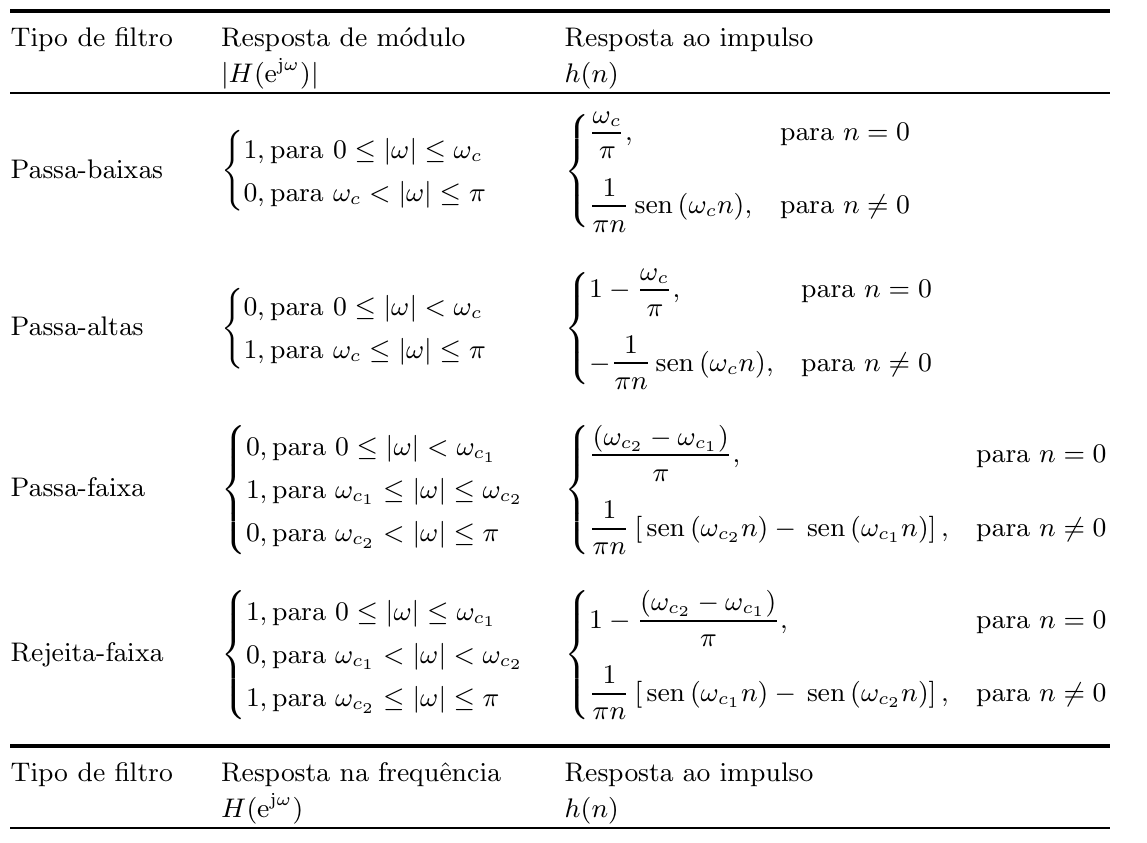

# Filtro Passa Baixa Ideal 



In [4]:
@njit(parallel=True)
def low_pass(N, fc, fs):
    """
    Calcula os coeficientes h[n] de um filtro FIR passa-baixa ideal
    usando um laço 'for' explícito.

    Argumentos:
    N (int): Ordem do filtro (número de coeficientes).
    fc (float): Frequência de corte (em Hertz).
    fs (float): Frequência de amostragem (em Hertz).

    Retorna:
    numpy.ndarray: Vetor de coeficientes h[n] do filtro.
    """
    
    # 1. CONVERSÃO: Calcula a frequência de corte digital (rad/amostra)
    #    a partir das frequências em Hertz.
    wc = 2 * np.pi * (fc / fs)
    
    # 2. Aloca um vetor 'h' vazio (cheio de zeros)
    h = np.zeros(N)
    
    # 3. Calcula o ponto médio (atraso)
    M = (N - 1) / 2
    
    # 4. Itera por cada índice 'n' do filtro
    for n in prange(N):
        # 5. Calcula o eixo 'n' centrado
        n_desloc = n - M
        
        # 6. Trata o caso especial (n = M)
        # Se n_shifted == 0, o limite é wc/pi
        if n_desloc == 0:
            h[n] = wc / np.pi
        else:
            # 7. Calcula todos os outros valores
            # Fórmula: sin(wc * n_desloc) / (pi * n_desloc)
            h[n] = np.sin(wc * n_desloc) / (np.pi * n_desloc)

    return h

## Plotando os Coeficientes,  Magnitude e Fase do Filtro Passa-Baixa 

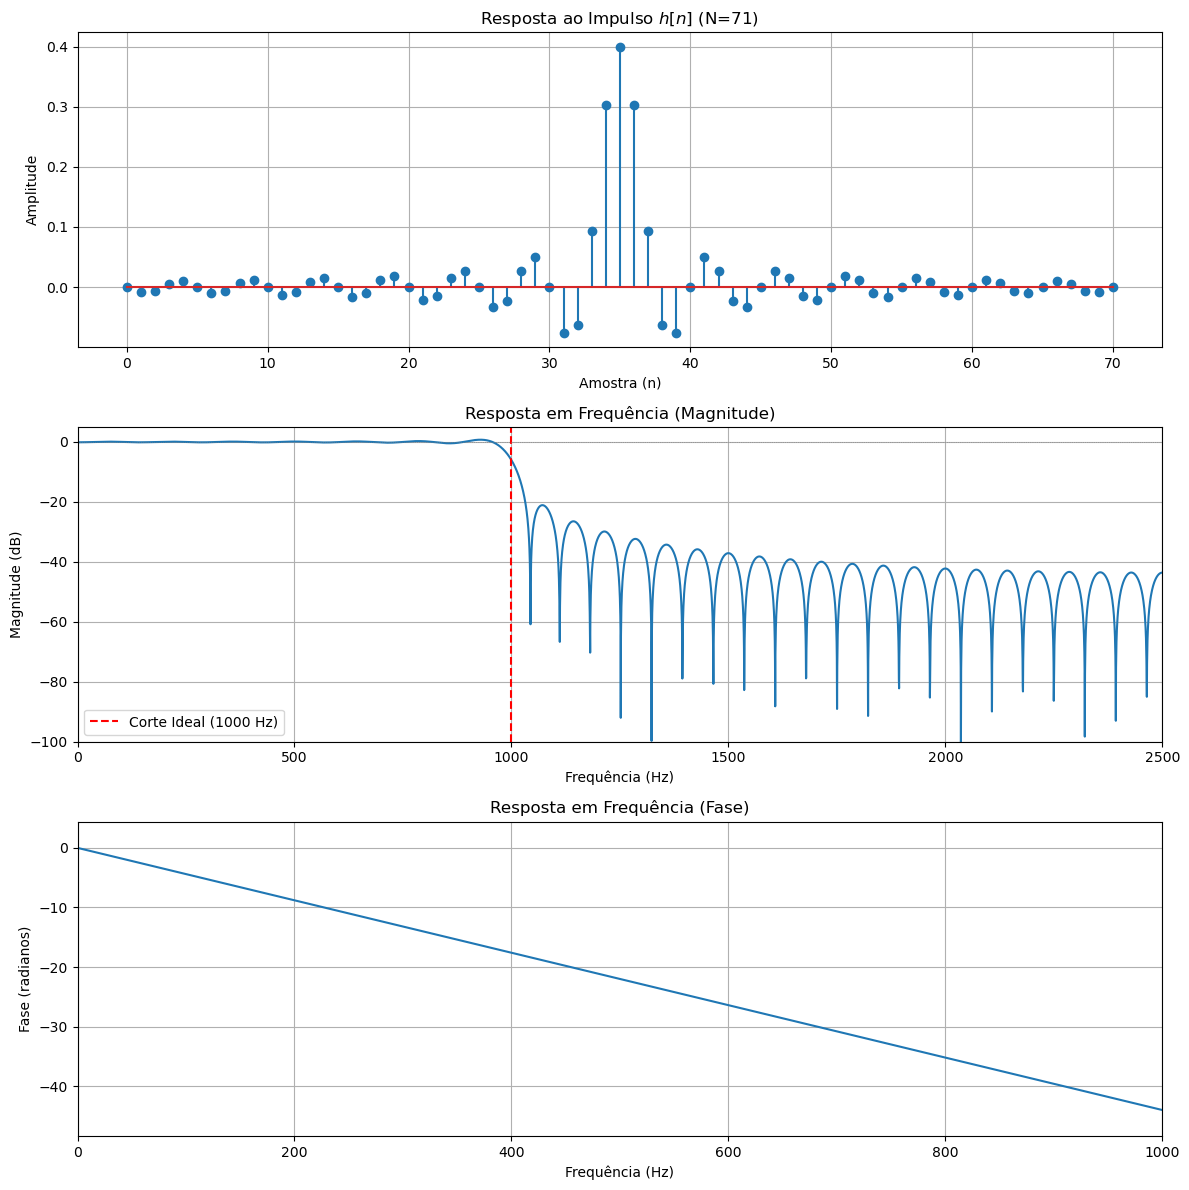

In [5]:
# Parâmetros do Filtro
N = 71     # Ordem do filtro (número de coeficientes)
                
fs = 5000        # Frequência de amostragem (Hz)
fc = 1000        # Frequência de corte (Hz) 

#Coeficientes do filtro

h = low_pass(N, fc, fs)

# CALCULAR A RESPOSTA EM FREQUÊNCIA (W e H)
# w: vetor de frequências em rad/amostra
# H: vetor da resposta em frequência (complexa)
# worN= aumenta a resolução do gráfico
w, H = freqz(h, worN=fs)

# ---------------------------------------------------
f_hz = (w / (2 * np.pi)) * fs
db_magnitude = 20 * np.log10(np.abs(H) + 1e-9)

# Cálculo da fase
phase_rad = np.angle(H)

# np.unwrap() remove os saltos de 2*pi para vermos a linha reta
phase_unwrapped = np.unwrap(phase_rad)

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Resposta ao Impulso (em axs[0]) 
axs[0].stem(np.arange(N), h)
axs[0].set_title(f'Resposta ao Impulso $h[n]$ (N={N})')
axs[0].set_xlabel('Amostra (n)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Plot 2: Resposta em Frequência (Magnitude) (em axs[1]) 
axs[1].plot(f_hz, db_magnitude)
axs[1].axvline(fc, color='red', linestyle='--', label=f'Corte Ideal ({fc} Hz)')
axs[1].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axs[1].set_title('Resposta em Frequência (Magnitude)')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (dB)')
axs[1].set_ylim(-100, 5)
axs[1].set_xlim(0, fs / 2)
axs[1].legend()
axs[1].grid(True)

# Plot 3: Resposta em Frequência (Fase) (em axs[2]) 
axs[2].plot(f_hz, phase_unwrapped)
axs[2].set_title('Resposta em Frequência (Fase)')
axs[2].set_xlabel('Frequência (Hz)')
axs[2].set_ylabel('Fase (radianos)')
# 1. Limitar o eixo X para a banda passante (0 até fc)
axs[2].set_xlim(0, fc)

# Encontra o índice do array f_hz mais próximo de fc
zoom_index_limit = np.max(np.where(f_hz <= fc))

# A fase (desembrulhada) começa em 0 e desce
min_phase = phase_unwrapped[zoom_index_limit]
max_phase = 0 # A fase em 0 Hz é 0

# 3. Adiciona uma pequena margem (10%) no eixo Y
margin = np.abs(min_phase) * 0.1
axs[2].set_ylim(min_phase - margin, max_phase + margin)

axs[2].grid(True)


plt.tight_layout() # Ajusta os plots para não sobrepor
plt.show()

#  Aproximação de Filtros FIR com Funções-Janela

Afim de evitar as respostas ao impulso com duração infinita dados os filtros ideais, logo levando a filtros não-realizaveis, devemos fazer uma aproximação dos filtro FIR via funções-janela multiplicando a resposta ao impulso $h(n)$ por uma função-janela $w(n)$. 

A janela $w(n)$ tem que ser projetada de forma a introduzir um mínimo de desvio em relação à resposta na frequência ideal. Os coeficientes da resposta ao impulso resultante $h'(n)$ se tornam

$h'(n) = h(n)w(n).$

No domínio da frequência, tal multiplicação corresponde à convolução periódica entre as respostas na frequência do filtro ideal, $H(e^{j\omega})$, e da função-janela. $W(e^{j\omega})$, isto é:

$H'(e^{j\omega}) = \frac{1}{2\pi} \int_{-\pi}^{\pi} H(e^{j\omega'})W(e^{j(\omega-\omega')})d\omega'.$

Podemos inferir, então, que uma boa janela é uma sequência de comprimento finito cuja resposta na frequência, quando convolvida com uma resposta na frequência ideal, produz a menor distorção possível.

Isso significa que devemos encontrar uma janela de comprimento finito cuja resposta na frequência tenha a maior parte de sua energia concentrada em torno de $\omega = 0$.

## Janelas de Hamming

A janela de Hamming generalizada é definida como

$w_{H}(n) = \begin{cases} \alpha + (1-\alpha) \cos \frac{2\pi n}{M}, & \text{para } |n| \le M/2 \\ 0, & \text{para } |n| > M/2, \end{cases}$
com $0 \le \alpha \le 1$.

 Essa janela generalizada é chamada de janela de Hamming quando $\alpha = 0,54$, e quando $\alpha = 0,5$ é conhecida como janela de Hann ou Hanning. A resposta na frequência para a janela de Hamming generalizada pode ser expressa com base na resposta na frequência da janela retangular. Primeiramente, escrevemos a equação como

$w_{H}(n) = w_{r}(n) \left[ \alpha + (1-\alpha) \cos \frac{2\pi n}{M} \right].$

In [6]:
#Janela de Hamming
@njit
def hamming_window(N):
    """
    Gera uma janela de Hamming de tamanho N.

    Argumentos:
    N (int): Tamanho da janela.

    Retorna:
    numpy.ndarray: Vetor contendo a janela de Hamming.
    """
    M = N - 1
    n = np.arange(N)
    alpha = 0.54
    window_h = alpha - (1 - alpha) * np.cos((2 * np.pi * n) / M)
    return window_h


#### $h'(n) = h(n)w(n).$

In [7]:
@njit
def LP_hamming(N, fc, fs):
  
    # 1. Calcula os coeficientes do filtro passa-baixa ideal
    h_ideal = low_pass(N, fc, fs)
    
    # 2. Gera a janela de Hamming
    window_h = hamming_window(N)
    
    # 3. Aplica a janela aos coeficientes ideais
    h_windowed = h_ideal * window_h
    
    h_windowed /= np.sum(h_windowed)  # Normaliza para ganho DC = 1
    
    return h_windowed, window_h

# Plote do Filtro de Hamming Passa-Baixa

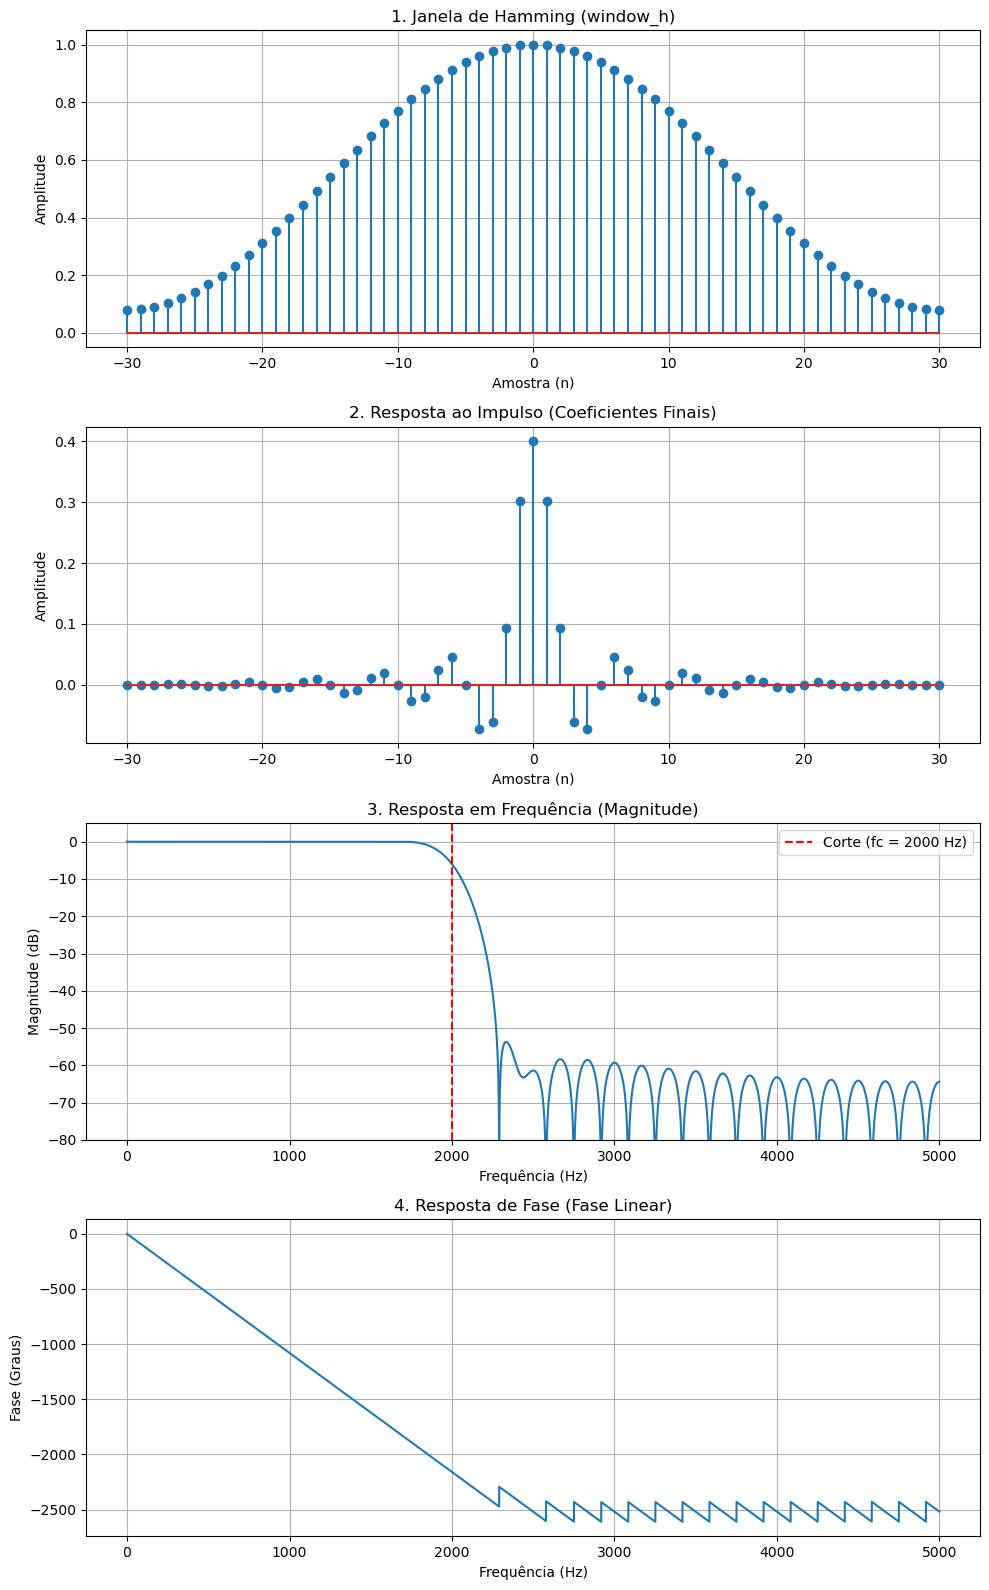

In [8]:
N = 61                # Ordem do filtro (tamanho)
fs = 10000            # Frequência de amostragem (12 kHz)
fc = 2000             # Frequência de corte (5 kHz)

# Cria o eixo de tempo 't' centrado em zero
t = np.arange(N) - (N - 1) / 2
hamming_windowed, window_h = LP_hamming(N, fc, fs)

w, H = freqz(hamming_windowed, 1, worN=8192, fs=fs)

# --- 5. Geração dos Gráficos em 'axs' ---
fig, axs = plt.subplots(4, 1, figsize=(10, 16)) 

# Gráfico 1: Janela de Hamming 
axs[0].stem(t, window_h, 'o-')
axs[0].set_title("1. Janela de Hamming (window_h)")
axs[0].set_xlabel("Amostra (n)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
# 

# Gráfico 2: Resposta ao Impulso (Coeficientes)
axs[1].stem(t, hamming_windowed, 'o-')
axs[1].set_title("2. Resposta ao Impulso (Coeficientes Finais)")
axs[1].set_xlabel("Amostra (n)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)

# Gráfico 3: Módulo em dB
magnitude_db = 20 * np.log10(np.abs(H))
axs[2].plot(w, magnitude_db)
axs[2].set_title("3. Resposta em Frequência (Magnitude)")
axs[2].set_xlabel("Frequência (Hz)")
axs[2].set_ylabel("Magnitude (dB)")
axs[2].axvline(fc, color='r', linestyle='--', label=f'Corte (fc = {fc} Hz)')
axs[2].set_ylim(-80, 5) 
axs[2].grid(True)
axs[2].legend()

# Gráfico 4: Fase 
phase = np.unwrap(np.angle(H))
phase_degrees = np.rad2deg(phase)

axs[3].plot(w, phase_degrees)
axs[3].set_title("4. Resposta de Fase (Fase Linear)")
axs[3].set_xlabel("Frequência (Hz)")
axs[3].set_ylabel("Fase (Graus)")
axs[3].grid(True)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()

        

## Aplicação do Filtro via biblioteca SoundDevice

Gravar um áudio com usando o microfone padrão do usuário e somar a um ruído randomico, com o intuito de usar o Filtro de Hamming Passa-Baixa. 

Analisar os espectros de frequência do sinais de entrada e saída.

In [9]:
import sounddevice as sd
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import scipy.signal as sig


fs = 44100
duracao = 8 # Vamos gravar por 5 segundos
N_filtro = 101 # Ordem do filtro
fc_filtro = 1000 # Frequência de corte (2000 Hz)

print("Gravação de 5 segundos iniciará em...")
time.sleep(1); print("3..."); time.sleep(1); print("2..."); time.sleep(1); print("1... FALE e ASSOBIE!")

# 1. Grava o áudio
meu_audio = sd.rec(int(duracao * fs), samplerate=fs, channels=1, dtype='float32')
sd.wait() # Espera a gravação terminar
print("Gravação completa.")
time.sleep(0.5)


ruido = np.random.normal(0, 0.1, meu_audio.shape)
meu_audio += ruido

# --- 3. PROJETA E APLICA O FILTRO ---
print(f"Projetando e aplicando filtro LP de {fc_filtro} Hz...")

# 3a. Projeta o filtro
# A função está retornando uma tupla, ex: (array([0.1, 0.2, ...]),)
h_filtro_output = LP_hamming(N=N_filtro, fc=fc_filtro, fs=fs)

# 3b. Aplica o filtro
audio_1d = meu_audio.flatten() # Este é float32

# -----------------

# 1. Checa se é uma tupla e extrai o primeiro elemento (o array)
if isinstance(h_filtro_output, tuple):
    h_filtro = h_filtro_output[0] 
else:
    h_filtro = h_filtro_output # Caso já esteja correto

# 2. Converte o array para float32 para bater com o áudio
h_filtro_32 = h_filtro.astype(np.float32)
# -----------------

# filtro de 32 bits na função
audio_filtrado = sig.lfilter(h_filtro_32, 1.0, audio_1d)

print("Filtro aplicado.")

# --- 4. PLOTS DE COMPARAÇÃO (ANTES E DEPOIS) ---
print("Calculando e plotando espectros...")

# Cria os eixos para 2 gráficos (2 linhas, 1 coluna)
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True, sharey=True)

# 4a. FFT do Áudio ORIGINAL
N = len(audio_1d)
yf_orig = fft(audio_1d) 
xf_orig = fftfreq(N, 1 / fs)

N_half = N // 2
xf_pos = xf_orig[:N_half]
yf_db_orig = 20 * np.log10(np.abs(yf_orig[:N_half]) + 1e-12)

# Plot do Original
axs[0].plot(xf_pos, yf_db_orig)
axs[0].set_title("Espectro ANTES do Filtro (Original)")
axs[0].set_ylabel("Magnitude (dB)")
axs[0].grid(True)

# 4b. FFT do Áudio FILTRADO
yf_filt = fft(audio_filtrado) 
# xf é o mesmo
yf_db_filt = 20 * np.log10(np.abs(yf_filt[:N_half]) + 1e-12)

# Plot do Filtrado
axs[1].plot(xf_pos, yf_db_filt, color='r')
axs[1].axvline(fc_filtro, color='g', linestyle='--', label=f'Corte (fc = {fc_filtro} Hz)')
axs[1].set_title("Espectro DEPOIS do Filtro (Hamming LP)")
axs[1].set_xlabel("Frequência (Hz)")
axs[1].set_ylabel("Magnitude (dB)")
axs[1].grid(True)
axs[1].legend()

# Ajustes finais dos eixos
max_db = np.max(yf_db_orig)
plt.xlim(0, 10000) # Foco em 0-10kHz
plt.ylim(max_db - 80, max_db + 5) # Janela de 80dB


# --- 5. TOCAR OS ÁUDIOS ---
print("\nReproduzindo o áudio ORIGINAL ...")
sd.play(meu_audio, fs)
sd.wait() # Espera a reprodução terminar
time.sleep(0.5)

print("Reproduzindo o áudio FILTRADO (som 'abafado')...")
sd.play(audio_filtrado, fs)
sd.wait() # Espera a reprodução terminar

print("\nConcluído.")

Gravação de 5 segundos iniciará em...
3...
2...
1... FALE e ASSOBIE!


PortAudioError: Error querying device -1

### Repetir o Áudio Original e o Áudio Filtrado

In [ ]:
sd.play(meu_audio, fs)
sd.wait() 
time.sleep(0.5)

sd.play(audio_filtrado, fs)

In [ ]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)
def high_pass(N, fc, fs):
    """
    Calcula os coeficientes h[n] de um filtro FIR passa-alta ideal
    baseado na fórmula fornecida na imagem.

    Argumentos:
    N (int): Ordem do filtro (número de coeficientes).
    fc (float): Frequência de corte (em Hertz).
    fs (float): Frequência de amostragem (em Hertz).

    Retorna:
    numpy.ndarray: Vetor de coeficientes h[n] do filtro.
    """
    
    # 1. CONVERSÃO: Calcula a frequência de corte digital (rad/amostra)
    wc = 2 * np.pi * (fc / fs)
    
    # 2. Aloca o vetor 'h'
    h = np.zeros(N)
    
    # 3. Calcula o ponto médio (atraso de grupo para fase linear)
    M = (N - 1) / 2
    
    # 4. Itera por cada índice 'n' do filtro
    for n in prange(N):
        # 5. Calcula o eixo 'n' centrado (equivalente ao 'n' da fórmula matemática)
        n_desloc = n - M
        
        # 6. Trata o caso especial (n = 0 na fórmula matemática)
        if n_desloc == 0:
            # Fórmula da imagem para n=0: 1 - (wc / pi)
            h[n] = 1 - (wc / np.pi)
        else:
            # 7. Calcula todos os outros valores
            # Fórmula da imagem para n!=0: - (1 / (pi*n)) * sin(wc*n)
            h[n] = -np.sin(wc * n_desloc) / (np.pi * n_desloc)

    return h

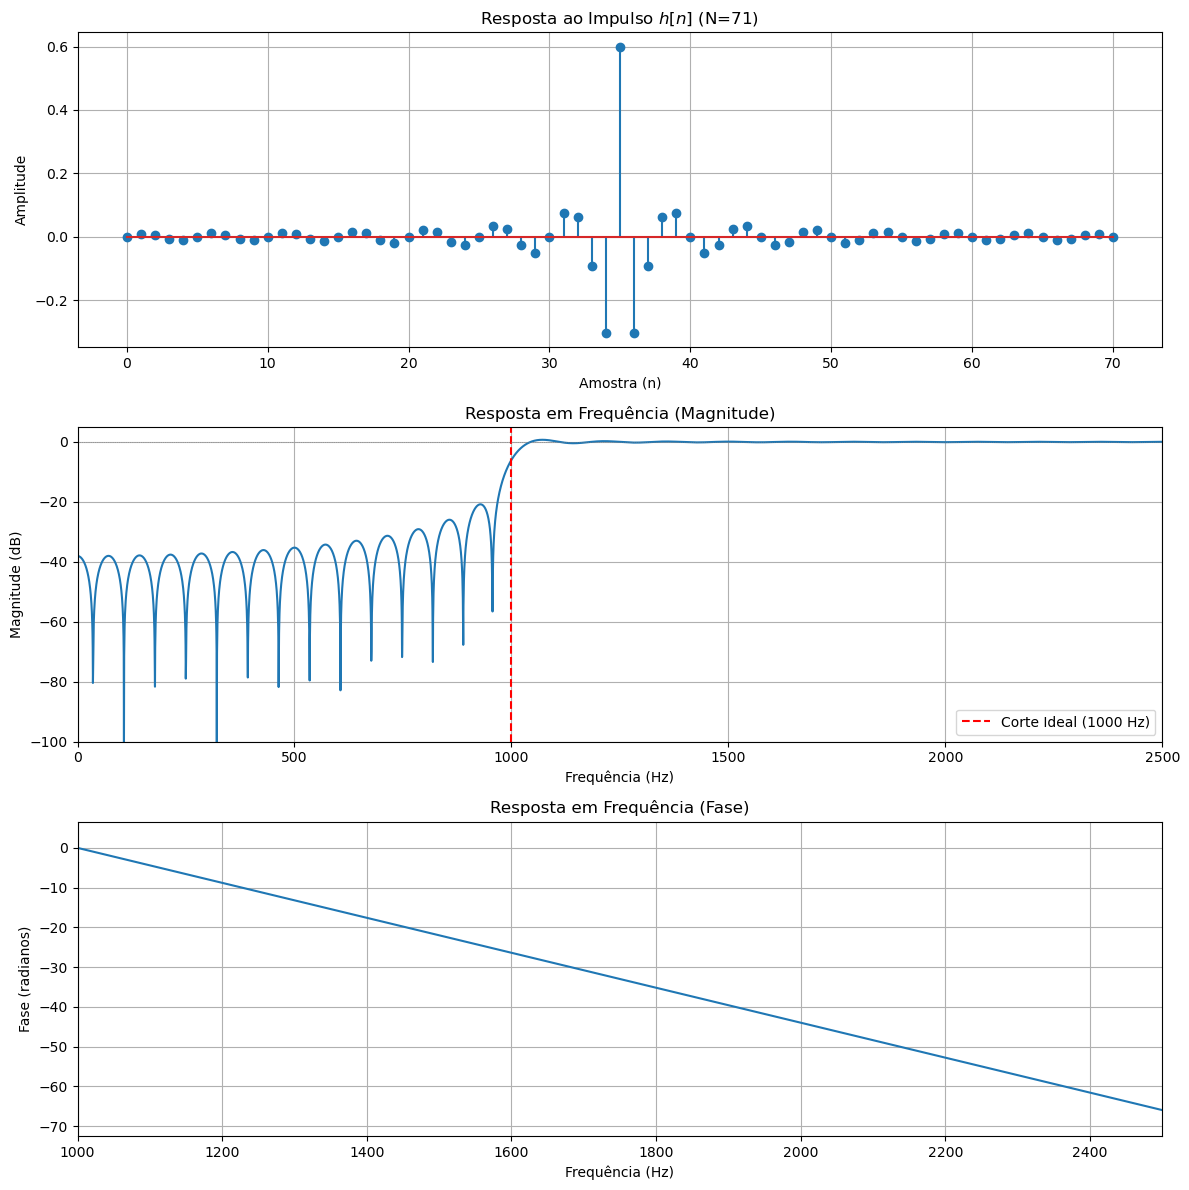

In [ ]:
# Parâmetros do Filtro
N = 71     # Ordem do filtro (número de coeficientes)
                
fs = 5000        # Frequência de amostragem (Hz)
fc = 1000        # Frequência de corte (Hz) 

#Coeficientes do filtro

h = high_pass(N, fc, fs)

# CALCULAR A RESPOSTA EM FREQUÊNCIA (W e H)
# w: vetor de frequências em rad/amostra
# H: vetor da resposta em frequência (complexa)
# worN= aumenta a resolução do gráfico
w, H = freqz(h, worN=fs)

# ---------------------------------------------------
f_hz = (w / (2 * np.pi)) * fs
db_magnitude = 20 * np.log10(np.abs(H) + 1e-9)

# Cálculo da fase
phase_rad = np.angle(H)

# np.unwrap() remove os saltos de 2*pi para vermos a linha reta
phase_unwrapped = np.unwrap(phase_rad)

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Resposta ao Impulso (em axs[0]) 
axs[0].stem(np.arange(N), h)
axs[0].set_title(f'Resposta ao Impulso $h[n]$ (N={N})')
axs[0].set_xlabel('Amostra (n)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Plot 2: Resposta em Frequência (Magnitude) (em axs[1]) 
axs[1].plot(f_hz, db_magnitude)
axs[1].axvline(fc, color='red', linestyle='--', label=f'Corte Ideal ({fc} Hz)')
axs[1].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axs[1].set_title('Resposta em Frequência (Magnitude)')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (dB)')
axs[1].set_ylim(-100, 5)
axs[1].set_xlim(0, fs / 2)
axs[1].legend()
axs[1].grid(True)

# Plot 3: Resposta em Frequência (Fase) (em axs[2]) 
# Plot 3: Resposta em Frequência (Fase)
axs[2].plot(f_hz, phase_unwrapped)
axs[2].set_title('Resposta em Frequência (Fase)')
axs[2].set_xlabel('Frequência (Hz)')
axs[2].set_ylabel('Fase (radianos)')


# Como é passa-alta, queremos ver de 1000Hz para cima
axs[2].set_xlim(fc, fs / 2) 


# Pegamos os índices onde a frequência é MAIOR que fc
passband_indices = np.where(f_hz >= fc)
min_phase = np.min(phase_unwrapped[passband_indices])
max_phase = np.max(phase_unwrapped[passband_indices])

# Margem visual
margin = np.abs(max_phase - min_phase) * 0.1
axs[2].set_ylim(min_phase - margin, max_phase + margin)

axs[2].grid(True)

plt.tight_layout()
plt.show()